In [ ]:
!pip -q install mne mne-bids scikit-learn tensorflow joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 18.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
import os
import glob
import zipfile
import warnings
import random
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    auc
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping

import joblib

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

print("MNE:", mne.__version__)
print("TensorFlow:", tf.__version__)

MNE: 1.13.2
TensorFlow: 2.20.0


In [ ]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
PROJECT_NAME = "P300 EEG-Based BCI"

DATASET_ID = "nm000351"

N_SUBJECTS = 5

TARGET_CODE = 2
NONTARGET_CODE = 1

LOW_FREQ = 0.1
HIGH_FREQ = 30.0

NOTCH_FREQ = 60.0

TMIN = 0.0
TMAX = 1.0

DOWNSAMPLE_FACTOR = 4

print("Project:", PROJECT_NAME)
print("Dataset:", DATASET_ID)
print("Subjects:", N_SUBJECTS)
print("Target:", TARGET_CODE)
print("Non-target:", NONTARGET_CODE)

Project: P300 EEG-Based BCI
Dataset: nm000351
Subjects: 5
Target: 2
Non-target: 1


In [ ]:
from google.colab import files

print("Select eggtest.zip")

uploaded = files.upload()

print("\nUpload completed.")

for filename in uploaded:
    print(filename)

Select eggtest.zip


Saving eggtest.zip to eggtest.zip

Upload completed.
eggtest.zip


In [ ]:
import os

print("Files in /content:\n")

for item in os.listdir("/content"):
    print(item)

Files in /content:

.config
eggtest.zip
sample_data


In [ ]:
import glob

zip_files = glob.glob("/content/*.zip")

print("ZIP files found:")

for f in zip_files:
    print(f)

if len(zip_files) == 0:
    raise FileNotFoundError(
        "❌ No ZIP file found. Please upload eggtest.zip."
    )

ZIP_PATH = "/content/eggtest.zip"

if not os.path.exists(ZIP_PATH):
    ZIP_PATH = zip_files[0]

print("\nUsing ZIP:")
print(ZIP_PATH)

ZIP files found:
/content/eggtest.zip

Using ZIP:
/content/eggtest.zip


In [ ]:
import zipfile
import os

EXTRACT_PATH = "/content/bigP3BCI"

os.makedirs(EXTRACT_PATH, exist_ok=True)

print("Extracting eggtest.zip...")
print("Please wait...")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✅ Extraction completed!")

Extracting eggtest.zip...
Please wait...
✅ Extraction completed!


In [ ]:
print("Extracted contents:\n")

for item in os.listdir("/content/bigP3BCI"):
    print(item)

Extracted contents:

dataset_description.json
sub-3
.gitignore
participants.tsv
README.md
sub-1
sub-5
.bidsignore
sub-2
sub-4
participants.json


In [ ]:
import os

print("Searching for subjects...\n")

for root, dirs, files in os.walk("/content/bigP3BCI"):
    for d in dirs:
        if d.lower().startswith("sub-"):
            print(os.path.join(root, d))

Searching for subjects...

/content/bigP3BCI/sub-3
/content/bigP3BCI/sub-1
/content/bigP3BCI/sub-5
/content/bigP3BCI/sub-2
/content/bigP3BCI/sub-4


In [ ]:
# CELL 12 — Find ALL BDF files robustly

import os

DATA_ROOT = "/content/bigP3BCI"

eeg_files = []

for root, dirs, files in os.walk(DATA_ROOT):
    for file in files:
        if file.lower().endswith(".bdf"):
            eeg_files.append(os.path.join(root, file))

eeg_files = sorted(eeg_files)

print("DATA ROOT:")
print(DATA_ROOT)

print("\nTotal BDF files found:", len(eeg_files))

if len(eeg_files) == 0:
    print("\n❌ No BDF files found.")
    print("\nChecking whether the dataset folder exists:")
    print(os.path.exists(DATA_ROOT))
else:
    print("\n✅ BDF files found:\n")
    for file in eeg_files[:20]:
        print(file)

DATA ROOT:
/content/bigP3BCI

Total BDF files found: 60

✅ BDF files found:

/content/bigP3BCI/sub-1/ses-0/eeg/sub-1_ses-0_task-p300_run-0_eeg.bdf
/content/bigP3BCI/sub-1/ses-0/eeg/sub-1_ses-0_task-p300_run-1_eeg.bdf
/content/bigP3BCI/sub-1/ses-0/eeg/sub-1_ses-0_task-p300_run-2_eeg.bdf
/content/bigP3BCI/sub-1/ses-0/eeg/sub-1_ses-0_task-p300_run-3_eeg.bdf
/content/bigP3BCI/sub-1/ses-0/eeg/sub-1_ses-0_task-p300_run-4_eeg.bdf
/content/bigP3BCI/sub-1/ses-0/eeg/sub-1_ses-0_task-p300_run-5_eeg.bdf
/content/bigP3BCI/sub-1/ses-1/eeg/sub-1_ses-1_task-p300_run-0_eeg.bdf
/content/bigP3BCI/sub-1/ses-1/eeg/sub-1_ses-1_task-p300_run-1_eeg.bdf
/content/bigP3BCI/sub-1/ses-1/eeg/sub-1_ses-1_task-p300_run-2_eeg.bdf
/content/bigP3BCI/sub-1/ses-1/eeg/sub-1_ses-1_task-p300_run-3_eeg.bdf
/content/bigP3BCI/sub-1/ses-1/eeg/sub-1_ses-1_task-p300_run-4_eeg.bdf
/content/bigP3BCI/sub-1/ses-1/eeg/sub-1_ses-1_task-p300_run-5_eeg.bdf
/content/bigP3BCI/sub-2/ses-0/eeg/sub-2_ses-0_task-p300_run-0_eeg.bdf
/content/bigP

In [ ]:
# CELL 13 — Display BDF files by subject

from collections import defaultdict

subject_files = defaultdict(list)

for file in eeg_files:
    parts = file.split(os.sep)

    # Find the subject folder
    subject = next(
        (p for p in parts if p.startswith("sub-")),
        None
    )

    if subject is not None:
        subject_files[subject].append(file)

print("EEG files by subject:\n")

for subject in sorted(subject_files):
    print(f"{subject}: {len(subject_files[subject])} BDF files")

    for file in subject_files[subject][:5]:
        print("   ", os.path.basename(file))

    if len(subject_files[subject]) > 5:
        print("    ...")

    print()

EEG files by subject:

sub-1: 12 BDF files
    sub-1_ses-0_task-p300_run-0_eeg.bdf
    sub-1_ses-0_task-p300_run-1_eeg.bdf
    sub-1_ses-0_task-p300_run-2_eeg.bdf
    sub-1_ses-0_task-p300_run-3_eeg.bdf
    sub-1_ses-0_task-p300_run-4_eeg.bdf
    ...

sub-2: 12 BDF files
    sub-2_ses-0_task-p300_run-0_eeg.bdf
    sub-2_ses-0_task-p300_run-1_eeg.bdf
    sub-2_ses-0_task-p300_run-2_eeg.bdf
    sub-2_ses-0_task-p300_run-3_eeg.bdf
    sub-2_ses-0_task-p300_run-4_eeg.bdf
    ...

sub-3: 12 BDF files
    sub-3_ses-0_task-p300_run-0_eeg.bdf
    sub-3_ses-0_task-p300_run-1_eeg.bdf
    sub-3_ses-0_task-p300_run-2_eeg.bdf
    sub-3_ses-0_task-p300_run-3_eeg.bdf
    sub-3_ses-0_task-p300_run-4_eeg.bdf
    ...

sub-4: 12 BDF files
    sub-4_ses-0_task-p300_run-0_eeg.bdf
    sub-4_ses-0_task-p300_run-1_eeg.bdf
    sub-4_ses-0_task-p300_run-2_eeg.bdf
    sub-4_ses-0_task-p300_run-3_eeg.bdf
    sub-4_ses-0_task-p300_run-4_eeg.bdf
    ...

sub-5: 12 BDF files
    sub-5_ses-0_task-p300_run-0_eeg.bdf
 

In [ ]:
# CELL 14 — BDF EEG loader

import mne

def load_raw_bdf(file_path):
    print("Loading:")
    print(file_path)

    raw = mne.io.read_raw_bdf(
        file_path,
        preload=True,
        verbose=False
    )

    return raw

print("✅ BDF loader is ready.")

✅ BDF loader is ready.


In [ ]:
# CELL 15 — Load one BDF EEG recording

import mne

if not eeg_files:
    raise RuntimeError(
        "❌ eeg_files is empty. Run Cell 12 again."
    )

first_file = eeg_files[0]

print("Loading EEG file:")
print(first_file)
print("\nPlease wait...")

raw = mne.io.read_raw_bdf(
    first_file,
    preload=True,
    verbose=False
)

print("\n✅ EEG loaded successfully!")
print(raw)

Loading EEG file:
/content/bigP3BCI/sub-1/ses-0/eeg/sub-1_ses-0_task-p300_run-0_eeg.bdf

Please wait...

✅ EEG loaded successfully!
<RawBDF | sub-1_ses-0_task-p300_run-0_eeg.bdf, 32 x 118784 (464.0 s), ~29.0 MiB, data loaded>


In [ ]:
def load_raw_eeg(file_path):

    extension = os.path.splitext(file_path)[1].lower()

    print("\nLoading:")
    print(file_path)

    if extension == ".vhdr":

        raw = mne.io.read_raw_brainvision(
            file_path,
            preload=True,
            verbose=False
        )

    elif extension == ".edf":

        raw = mne.io.read_raw_edf(
            file_path,
            preload=True,
            verbose=False
        )

    elif extension == ".bdf":

        raw = mne.io.read_raw_bdf(
            file_path,
            preload=True,
            verbose=False
        )

    elif extension == ".set":

        raw = mne.io.read_raw_eeglab(
            file_path,
            preload=True,
            verbose=False
        )

    elif extension == ".fif":

        raw = mne.io.read_raw_fif(
            file_path,
            preload=True,
            verbose=False
        )

    else:

        raise ValueError(
            "Unsupported EEG format: " + extension
        )

    return raw

In [ ]:
# CELL 17 — Select EEG channels safely

print("Total channels:", len(raw.ch_names))
print("\nChannel names:")
print(raw.ch_names)

# Find EEG channels automatically
eeg_picks = mne.pick_types(
    raw.info,
    eeg=True,
    exclude=[]
)

print("\nNumber of EEG channels found:", len(eeg_picks))

if len(eeg_picks) == 0:
    raise RuntimeError(
        "❌ No EEG channels were detected. "
        "Please check the channel types in Cell 16."
    )

# Keep only EEG channels
raw_eeg = raw.copy().pick(eeg_picks)

print("\n✅ EEG channels selected successfully!")
print("Number of EEG channels:", len(raw_eeg.ch_names))
print("\nSelected channels:")
print(raw_eeg.ch_names)

Total channels: 32

Channel names:
['F3', 'Fz', 'F4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CP4', 'P3', 'Pz', 'P4', 'PO7', 'PO8', 'Oz', 'Fp1', 'Fp2', 'F7', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'CPz', 'P7', 'P5', 'PO3', 'POz', 'PO4', 'O1', 'O2']

Number of EEG channels found: 32

✅ EEG channels selected successfully!
Number of EEG channels: 32

Selected channels:
['F3', 'Fz', 'F4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CP4', 'P3', 'Pz', 'P4', 'PO7', 'PO8', 'Oz', 'Fp1', 'Fp2', 'F7', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'CPz', 'P7', 'P5', 'PO3', 'POz', 'PO4', 'O1', 'O2']


In [ ]:
print("Number of channels:", len(raw.ch_names))

print("\nChannels:")

for i, channel in enumerate(raw.ch_names):

    print(i, channel)

Number of channels: 32

Channels:
0 F3
1 Fz
2 F4
3 T7
4 C3
5 Cz
6 C4
7 T8
8 CP3
9 CP4
10 P3
11 Pz
12 P4
13 PO7
14 PO8
15 Oz
16 Fp1
17 Fp2
18 F7
19 F8
20 FC5
21 FC1
22 FC2
23 FC6
24 CPz
25 P7
26 P5
27 PO3
28 POz
29 PO4
30 O1
31 O2


In [ ]:
picks = mne.pick_types(
    raw.info,
    eeg=True,
    eog=False,
    stim=False,
    exclude="bads"
)

raw.pick(picks)

print("EEG channels after selection:")
print(len(raw.ch_names))

print(raw.ch_names)

EEG channels after selection:
32
['F3', 'Fz', 'F4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CP4', 'P3', 'Pz', 'P4', 'PO7', 'PO8', 'Oz', 'Fp1', 'Fp2', 'F7', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'CPz', 'P7', 'P5', 'PO3', 'POz', 'PO4', 'O1', 'O2']


In [ ]:
try:

    montage = mne.channels.make_standard_montage(
        "standard_1020"
    )

    raw.set_montage(
        montage,
        on_missing="ignore"
    )

    print("✅ Standard 10-20 montage applied.")

except Exception as e:

    print("Montage warning:")
    print(e)

✅ Standard 10-20 montage applied.


In [ ]:
raw.filter(
    l_freq=LOW_FREQ,
    h_freq=HIGH_FREQ,
    verbose=False
)

print(
    f"✅ Band-pass filter applied: "
    f"{LOW_FREQ}-{HIGH_FREQ} Hz"
)

✅ Band-pass filter applied: 0.1-30.0 Hz


In [ ]:
try:

    raw.notch_filter(
        freqs=NOTCH_FREQ,
        verbose=False
    )

    print(
        f"✅ {NOTCH_FREQ} Hz notch filter applied."
    )

except Exception as e:

    print("Notch filter warning:")
    print(e)

✅ 60.0 Hz notch filter applied.


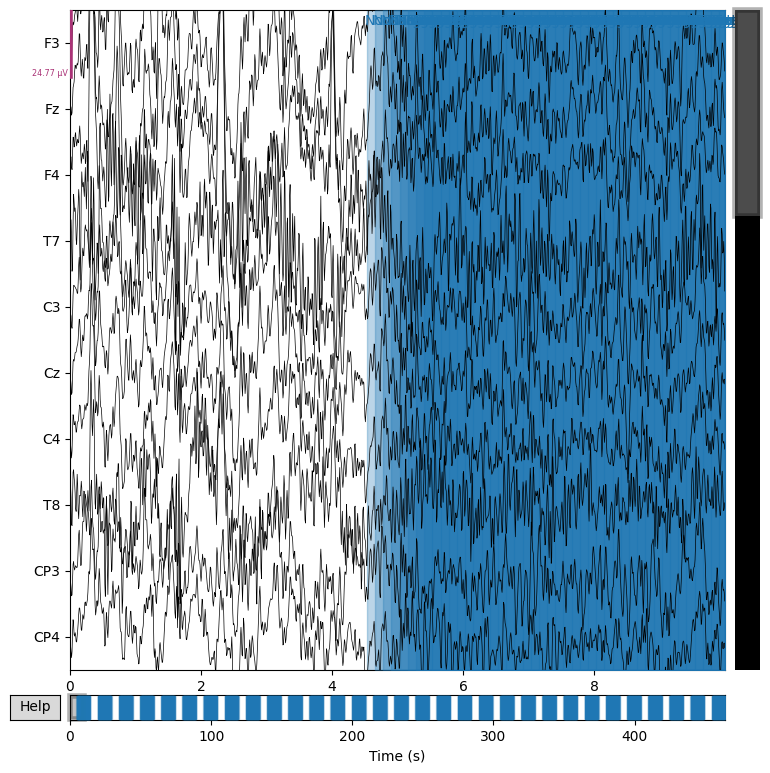

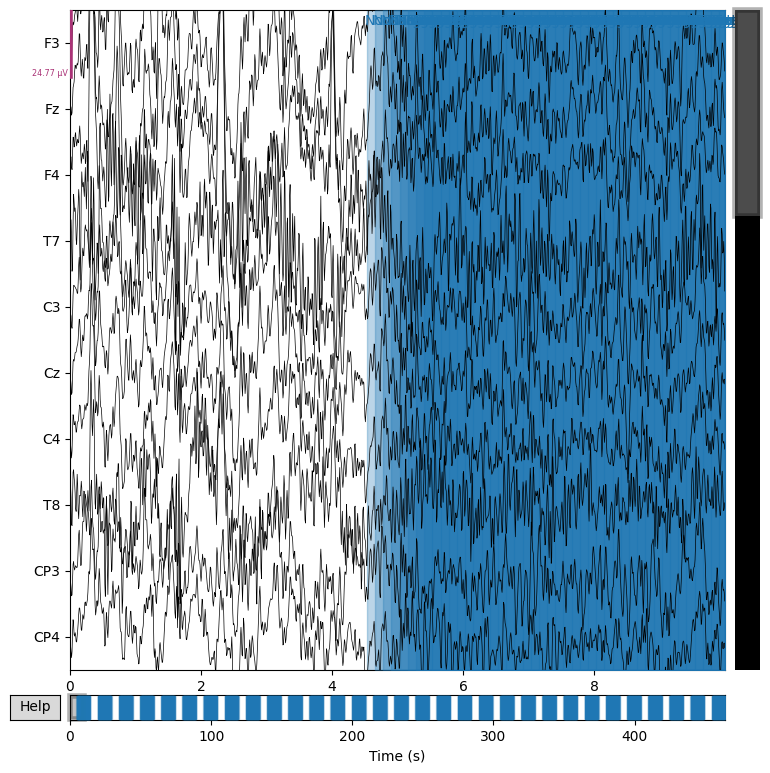

In [ ]:
raw.plot(
    duration=10,
    n_channels=min(10, len(raw.ch_names)),
    scalings="auto"
)

In [ ]:
print("Number of annotations:", len(raw.annotations))

print("\nAnnotations:")

for i, annotation in enumerate(raw.annotations[:50]):

    print(
        i,
        "Onset:",
        annotation["onset"],
        "Duration:",
        annotation["duration"],
        "Description:",
        annotation["description"]
    )

Number of annotations: 2232

Annotations:
0 Onset: 4.53125 Duration: 1.0 Description: NonTarget
1 Onset: 4.65625 Duration: 1.0 Description: NonTarget
2 Onset: 4.78125 Duration: 1.0 Description: NonTarget
3 Onset: 4.90625 Duration: 1.0 Description: NonTarget
4 Onset: 5.03125 Duration: 1.0 Description: NonTarget
5 Onset: 5.15625 Duration: 1.0 Description: NonTarget
6 Onset: 5.28125 Duration: 1.0 Description: NonTarget
7 Onset: 5.40625 Duration: 1.0 Description: NonTarget
8 Onset: 5.53125 Duration: 1.0 Description: NonTarget
9 Onset: 5.65625 Duration: 1.0 Description: NonTarget
10 Onset: 5.78125 Duration: 1.0 Description: NonTarget
11 Onset: 5.90625 Duration: 1.0 Description: NonTarget
12 Onset: 6.03125 Duration: 1.0 Description: NonTarget
13 Onset: 6.15625 Duration: 1.0 Description: NonTarget
14 Onset: 6.28125 Duration: 1.0 Description: NonTarget
15 Onset: 6.40625 Duration: 1.0 Description: NonTarget
16 Onset: 6.53125 Duration: 1.0 Description: NonTarget
17 Onset: 6.65625 Duration: 1.0 D

In [ ]:
events, event_id = mne.events_from_annotations(
    raw,
    verbose=False
)

print("Event ID:")
print(event_id)

print("\nNumber of events:", len(events))

Event ID:
{'NonTarget': 1}

Number of events: 2232


In [ ]:
print("Expected Target code:", TARGET_CODE)
print("Expected Non-target code:", NONTARGET_CODE)

print("\nAvailable event codes:")

for name, code in event_id.items():

    print(
        name,
        "->",
        code
    )

Expected Target code: 2
Expected Non-target code: 1

Available event codes:
NonTarget -> 1


In [ ]:
unique_codes, counts = np.unique(
    events[:, 2],
    return_counts=True
)

print("Event counts:\n")

for code, count in zip(
    unique_codes,
    counts
):

    print(
        "Code:",
        code,
        "Count:",
        count
    )

Event counts:

Code: 1 Count: 2232


In [ ]:
# DIAGNOSTIC — Check actual P300 events

print("event_id dictionary:")
print(event_id)

print("\nFirst 20 events:")
print(events[:20])

print("\nUnique event codes:")
print(sorted(set(events[:, 2])))

print("\nNumber of events:")
print(len(events))

event_id dictionary:
{'NonTarget': 1}

First 20 events:
[[1160    0    1]
 [1192    0    1]
 [1224    0    1]
 [1256    0    1]
 [1288    0    1]
 [1320    0    1]
 [1352    0    1]
 [1384    0    1]
 [1416    0    1]
 [1448    0    1]
 [1480    0    1]
 [1512    0    1]
 [1544    0    1]
 [1576    0    1]
 [1608    0    1]
 [1640    0    1]
 [1672    0    1]
 [1704    0    1]
 [1736    0    1]
 [1768    0    1]]

Unique event codes:
[np.int64(1)]

Number of events:
2232


In [ ]:
# CELL — Inspect the BIDS events.tsv file

import os
import pandas as pd

# Find the events.tsv corresponding to the BDF file
bdf_file = first_file

events_tsv = bdf_file.replace("_eeg.bdf", "_events.tsv")

print("BDF file:")
print(bdf_file)

print("\nEvents TSV:")
print(events_tsv)

if not os.path.exists(events_tsv):
    raise FileNotFoundError(
        "❌ Matching events.tsv file was not found."
    )

# Read the BIDS events file
events_df = pd.read_csv(
    events_tsv,
    sep="\t"
)

print("\n✅ Events TSV loaded!")
print("Shape:", events_df.shape)

print("\nColumns:")
print(events_df.columns.tolist())

print("\nFirst 20 rows:")
display(events_df.head(20))

BDF file:
/content/bigP3BCI/sub-1/ses-0/eeg/sub-1_ses-0_task-p300_run-0_eeg.bdf

Events TSV:
/content/bigP3BCI/sub-1/ses-0/eeg/sub-1_ses-0_task-p300_run-0_events.tsv

✅ Events TSV loaded!
Shape: (2232, 5)

Columns:
['onset', 'duration', 'trial_type', 'value', 'sample']

First 20 rows:


,onset,duration,trial_type,value,sample
0,4.53125,1.0,NonTarget,1,1160
1,4.65625,1.0,NonTarget,1,1192
2,4.78125,1.0,NonTarget,1,1224
3,4.90625,1.0,NonTarget,1,1256
4,5.03125,1.0,NonTarget,1,1288
5,5.15625,1.0,NonTarget,1,1320
6,5.28125,1.0,NonTarget,1,1352
7,5.40625,1.0,NonTarget,1,1384
8,5.53125,1.0,NonTarget,1,1416
9,5.65625,1.0,NonTarget,1,1448


In [ ]:
# CELL — Inspect event information

for column in events_df.columns:
    print("\n==============================")
    print("COLUMN:", column)
    print("==============================")

    print(events_df[column].unique()[:30])


COLUMN: onset
[4.53125 4.65625 4.78125 4.90625 5.03125 5.15625 5.28125 5.40625 5.53125
 5.65625 5.78125 5.90625 6.03125 6.15625 6.28125 6.40625 6.53125 6.65625
 6.78125 6.90625 7.03125 7.15625 7.28125 7.40625 7.53125 7.65625 7.78125
 7.90625 8.03125 8.15625]

COLUMN: duration
[1.      0.96875 0.84375 0.71875 0.59375]

COLUMN: trial_type
['NonTarget']

COLUMN: value
[1]

COLUMN: sample
[1160 1192 1224 1256 1288 1320 1352 1384 1416 1448 1480 1512 1544 1576
 1608 1640 1672 1704 1736 1768 1800 1832 1864 1896 1928 1960 1992 2024
 2056 2088]


In [ ]:
# CELL — Find a recording containing BOTH Target and NonTarget events

import os
import pandas as pd

DATA_ROOT = "/content/bigP3BCI"

candidate_runs = []

for root, dirs, files in os.walk(DATA_ROOT):
    for file in files:
        if file.endswith("_events.tsv"):

            events_path = os.path.join(root, file)

            try:
                df = pd.read_csv(events_path, sep="\t")

                if "trial_type" in df.columns:

                    event_types = set(
                        df["trial_type"]
                        .dropna()
                        .astype(str)
                        .str.strip()
                    )

                    if "Target" in event_types and "NonTarget" in event_types:
                        candidate_runs.append(events_path)

            except Exception as e:
                print("Could not read:", events_path)
                print(e)

print("========================================")
print("RUNS WITH TARGET + NONTARGET")
print("========================================")

print("Number of suitable runs:", len(candidate_runs))

for i, path in enumerate(candidate_runs[:20]):
    print(i, path)


if len(candidate_runs) == 0:
    raise RuntimeError(
        "❌ No recording containing both Target and NonTarget was found."
    )

print("\n✅ Suitable recording found!")
print(candidate_runs[0])

RUNS WITH TARGET + NONTARGET
Number of suitable runs: 50
0 /content/bigP3BCI/sub-3/ses-1/eeg/sub-3_ses-1_task-p300_run-3_events.tsv
1 /content/bigP3BCI/sub-3/ses-1/eeg/sub-3_ses-1_task-p300_run-2_events.tsv
2 /content/bigP3BCI/sub-3/ses-1/eeg/sub-3_ses-1_task-p300_run-5_events.tsv
3 /content/bigP3BCI/sub-3/ses-1/eeg/sub-3_ses-1_task-p300_run-4_events.tsv
4 /content/bigP3BCI/sub-3/ses-1/eeg/sub-3_ses-1_task-p300_run-1_events.tsv
5 /content/bigP3BCI/sub-3/ses-0/eeg/sub-3_ses-0_task-p300_run-4_events.tsv
6 /content/bigP3BCI/sub-3/ses-0/eeg/sub-3_ses-0_task-p300_run-2_events.tsv
7 /content/bigP3BCI/sub-3/ses-0/eeg/sub-3_ses-0_task-p300_run-1_events.tsv
8 /content/bigP3BCI/sub-3/ses-0/eeg/sub-3_ses-0_task-p300_run-3_events.tsv
9 /content/bigP3BCI/sub-3/ses-0/eeg/sub-3_ses-0_task-p300_run-5_events.tsv
10 /content/bigP3BCI/sub-1/ses-1/eeg/sub-1_ses-1_task-p300_run-5_events.tsv
11 /content/bigP3BCI/sub-1/ses-1/eeg/sub-1_ses-1_task-p300_run-2_events.tsv
12 /content/bigP3BCI/sub-1/ses-1/eeg/sub-

In [ ]:
# CELL — Load the selected recording and create events

events_tsv = candidate_runs[0]

# Convert events.tsv path to corresponding BDF path
bdf_file = events_tsv.replace("_events.tsv", "_eeg.bdf")

print("BDF:")
print(bdf_file)

print("\nEvents TSV:")
print(events_tsv)

# Load EEG
raw = mne.io.read_raw_bdf(
    bdf_file,
    preload=True,
    verbose=False
)

# Select EEG channels
eeg_picks = mne.pick_types(
    raw.info,
    eeg=True,
    exclude=[]
)

raw_eeg = raw.copy().pick(eeg_picks)

print("\n✅ EEG loaded")
print("Channels:", len(raw_eeg.ch_names))

# Read BIDS events
events_df = pd.read_csv(
    events_tsv,
    sep="\t"
)

print("\nEvent types:")
print(events_df["trial_type"].value_counts())

# Create MNE events directly from the sample column
events = []

for _, row in events_df.iterrows():

    sample = int(row["sample"])
    trial_type = str(row["trial_type"]).strip()

    if trial_type == "NonTarget":
        code = 1

    elif trial_type == "Target":
        code = 2

    else:
        continue

    events.append([sample, 0, code])

events = np.array(events, dtype=int)

event_id = {
    "NonTarget": 1,
    "Target": 2
}

print("\nMNE event_id:")
print(event_id)

print("\nUnique event codes:")
print(np.unique(events[:, 2]))

print("\nTotal events:", len(events))

BDF:
/content/bigP3BCI/sub-3/ses-1/eeg/sub-3_ses-1_task-p300_run-3_eeg.bdf

Events TSV:
/content/bigP3BCI/sub-3/ses-1/eeg/sub-3_ses-1_task-p300_run-3_events.tsv

✅ EEG loaded
Channels: 32

Event types:
trial_type
NonTarget    770
Target        70
Name: count, dtype: int64

MNE event_id:
{'NonTarget': 1, 'Target': 2}

Unique event codes:
[1 2]

Total events: 840


In [ ]:
# CELL — Create Target and NonTarget P300 epochs

TMIN = 0.0
TMAX = 0.8

epochs = mne.Epochs(
    raw_eeg,
    events,
    event_id={
        "NonTarget": 1,
        "Target": 2
    },
    tmin=TMIN,
    tmax=TMAX,
    baseline=(0.0, 0.1),
    preload=True,
    reject_by_annotation=True,
    verbose=False
)

print("\n✅ P300 epochs created successfully!")

print(epochs)

print("\nNumber of epochs:", len(epochs))

print("\nEpoch shape:")
print(epochs.get_data().shape)

print("\nMeaning:")
print("(epochs, channels, time samples)")


✅ P300 epochs created successfully!
<Epochs | 840 events (all good), 0 – 0.801 s (baseline 0 – 0.1 s), ~42.3 MiB, data loaded,
 'NonTarget': 770
 'Target': 70>

Number of epochs: 840

Epoch shape:
(840, 32, 206)

Meaning:
(epochs, channels, time samples)


In [ ]:
X = epochs.get_data()

print("Epoch data shape:")
print(X.shape)

print("\nMeaning:")
print("(epochs, channels, time samples)")

Epoch data shape:
(840, 32, 206)

Meaning:
(epochs, channels, time samples)


In [ ]:
event_codes = epochs.events[:, 2]

print("Unique event codes:")
print(np.unique(event_codes, return_counts=True))

Unique event codes:
(array([1, 2]), array([770,  70]))


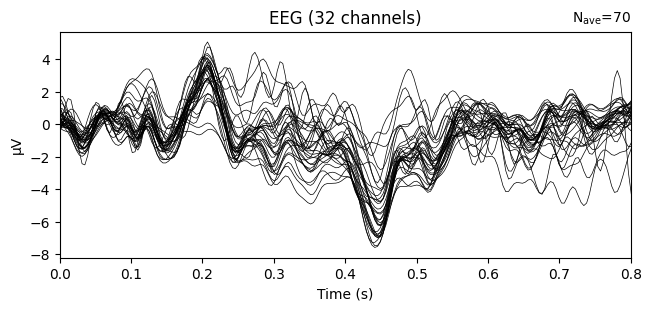

In [ ]:
target_evoked = epochs["Target"].average()

target_evoked.plot(
    spatial_colors=True
)

plt.show()

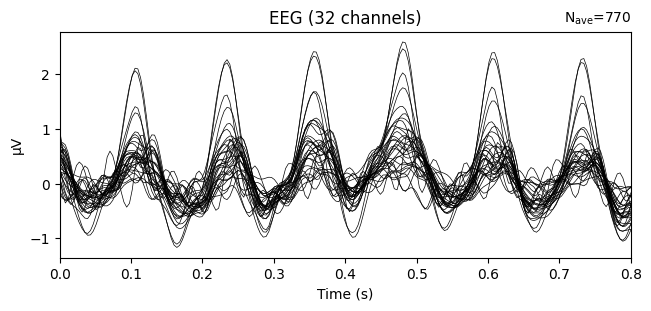

In [ ]:
nontarget_evoked = epochs["NonTarget"].average()

nontarget_evoked.plot(
    spatial_colors=True
)

plt.show()

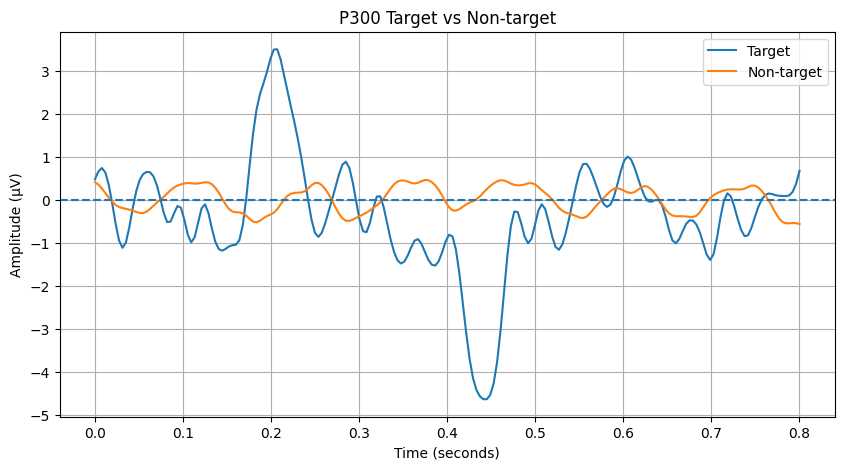

In [ ]:
channel_index = 0

plt.figure(figsize=(10, 5))

plt.plot(
    target_evoked.times,
    target_evoked.data[channel_index] * 1e6,
    label="Target"
)

plt.plot(
    nontarget_evoked.times,
    nontarget_evoked.data[channel_index] * 1e6,
    label="Non-target"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")

plt.title(
    "P300 Target vs Non-target"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
X = epochs.get_data()

event_codes = epochs.events[:, 2]

y = np.where(
    event_codes == TARGET_CODE,
    1,
    0
)

print("X:", X.shape)
print("y:", y.shape)

print("\nLabels:")
print(
    np.unique(
        y,
        return_counts=True
    )
)

X: (840, 32, 206)
y: (840,)

Labels:
(array([0, 1]), array([770,  70]))


In [ ]:
X_downsampled = X[
    :,
    :,
    ::DOWNSAMPLE_FACTOR
]

print("Original:")
print(X.shape)

print("\nAfter downsampling:")
print(X_downsampled.shape)

Original:
(840, 32, 206)

After downsampling:
(840, 32, 52)


In [ ]:
X_flat = X_downsampled.reshape(
    X_downsampled.shape[0],
    -1
)

print("Final ML input shape:")
print(X_flat.shape)

Final ML input shape:
(840, 1664)


In [ ]:
# CELL — Preprocess one subject using BIDS events.tsv

def preprocess_subject(subject_folder):

    subject_name = os.path.basename(subject_folder)

    print("\n")
    print("=" * 80)
    print("PROCESSING:", subject_name)
    print("=" * 80)

    subject_eeg_files = []

    # Find BDF files
    for root, dirs, files in os.walk(subject_folder):

        for filename in files:

            if filename.lower().endswith("_eeg.bdf"):

                subject_eeg_files.append(
                    os.path.join(root, filename)
                )

    subject_eeg_files = sorted(subject_eeg_files)

    print("EEG files:", len(subject_eeg_files))

    if len(subject_eeg_files) == 0:

        print("❌ No EEG BDF files for", subject_name)

        return None, None

    all_X = []
    all_y = []

    # --------------------------------------------------
    # Process every BDF file
    # --------------------------------------------------

    for file_path in subject_eeg_files:

        try:

            print("\nChecking:")
            print(os.path.basename(file_path))

            # Corresponding events.tsv
            events_tsv = file_path.replace(
                "_eeg.bdf",
                "_events.tsv"
            )

            if not os.path.exists(events_tsv):

                print("⚠️ events.tsv not found")
                continue

            # --------------------------------------------------
            # Read events.tsv
            # --------------------------------------------------

            events_df = pd.read_csv(
                events_tsv,
                sep="\t"
            )

            if "trial_type" not in events_df.columns:

                print("⚠️ trial_type column missing")
                continue

            # Get event types
            event_types = set(
                events_df["trial_type"]
                .dropna()
                .astype(str)
                .str.strip()
            )

            print("Event types:", event_types)

            # We need both classes
            if "Target" not in event_types:

                print("⚠️ Target not found")
                continue

            if "NonTarget" not in event_types:

                print("⚠️ NonTarget not found")
                continue

            # --------------------------------------------------
            # Load BDF
            # --------------------------------------------------

            raw = mne.io.read_raw_bdf(
                file_path,
                preload=True,
                verbose=False
            )

            # --------------------------------------------------
            # Select EEG channels
            # --------------------------------------------------

            eeg_picks = mne.pick_types(
                raw.info,
                eeg=True,
                eog=False,
                stim=False,
                exclude="bads"
            )

            if len(eeg_picks) == 0:

                print("⚠️ No EEG channels")
                continue

            raw.pick(eeg_picks)

            # --------------------------------------------------
            # Montage
            # --------------------------------------------------

            try:

                montage = mne.channels.make_standard_montage(
                    "standard_1020"
                )

                raw.set_montage(
                    montage,
                    on_missing="ignore"
                )

            except Exception:

                pass

            # --------------------------------------------------
            # Band-pass filter
            # --------------------------------------------------

            raw.filter(
                LOW_FREQ,
                HIGH_FREQ,
                verbose=False
            )

            # --------------------------------------------------
            # Notch filter
            # --------------------------------------------------

            try:

                raw.notch_filter(
                    NOTCH_FREQ,
                    verbose=False
                )

            except Exception:

                pass

            # --------------------------------------------------
            # Create MNE events from events.tsv
            # --------------------------------------------------

            event_list = []

            for _, row in events_df.iterrows():

                trial_type = str(
                    row["trial_type"]
                ).strip()

                sample = int(
                    row["sample"]
                )

                if trial_type == "NonTarget":

                    code = 1

                elif trial_type == "Target":

                    code = 2

                else:

                    continue

                event_list.append(
                    [sample, 0, code]
                )

            events = np.array(
                event_list,
                dtype=int
            )

            event_id = {
                "NonTarget": 1,
                "Target": 2
            }

            print(
                "Target events:",
                np.sum(events[:, 2] == 2)
            )

            print(
                "NonTarget events:",
                np.sum(events[:, 2] == 1)
            )

            # --------------------------------------------------
            # Create epochs
            # --------------------------------------------------

            epochs = mne.Epochs(
                raw,
                events,
                event_id=event_id,
                tmin=TMIN,
                tmax=TMAX,
                baseline=(0.0, 0.1),
                preload=True,
                reject_by_annotation=True,
                verbose=False
            )

            if len(epochs) == 0:

                print("⚠️ No valid epochs")
                continue

            # --------------------------------------------------
            # Get EEG data
            # --------------------------------------------------

            X_file = epochs.get_data()

            codes = epochs.events[:, 2]

            # Target = 1
            # NonTarget = 0

            y_file = np.where(
                codes == 2,
                1,
                0
            )

            print(
                "Original shape:",
                X_file.shape
            )

            # --------------------------------------------------
            # Downsample
            # --------------------------------------------------

            X_file = X_file[
                :,
                :,
                ::DOWNSAMPLE_FACTOR
            ]

            print(
                "After downsampling:",
                X_file.shape
            )

            # --------------------------------------------------
            # Flatten
            # --------------------------------------------------

            X_file = X_file.reshape(
                X_file.shape[0],
                -1
            )

            print(
                "After flattening:",
                X_file.shape
            )

            # Store
            all_X.append(X_file)
            all_y.append(y_file)

            print(
                "✅ Processed:",
                os.path.basename(file_path)
            )

        except Exception as e:

            print(
                "⚠️ Error:",
                os.path.basename(file_path)
            )

            print(
                "Reason:",
                e
            )

    # --------------------------------------------------
    # Combine all recordings
    # --------------------------------------------------

    if len(all_X) == 0:

        print(
            "\n❌ No usable recordings for",
            subject_name
        )

        return None, None

    X_subject = np.concatenate(
        all_X,
        axis=0
    )

    y_subject = np.concatenate(
        all_y,
        axis=0
    )

    print("\n" + "=" * 80)

    print(
        "FINAL:",
        subject_name
    )

    print(
        "X shape:",
        X_subject.shape
    )

    print(
        "y shape:",
        y_subject.shape
    )

    print(
        "Labels:",
        np.unique(
            y_subject,
            return_counts=True
        )
    )

    print("=" * 80)

    return X_subject, y_subject

In [ ]:
# CELL — Process all subjects and create subject_data

subject_data = {}

# Find subject folders directly from the dataset
selected_subjects = sorted([
    os.path.join(DATA_ROOT, folder)
    for folder in os.listdir(DATA_ROOT)
    if folder.startswith("sub-")
    and os.path.isdir(os.path.join(DATA_ROOT, folder))
])

print("Subjects to process:")
print(selected_subjects)

print("\n" + "=" * 80)
print("PROCESSING ALL SUBJECTS")
print("=" * 80)

for subject_folder in selected_subjects:

    subject_name = os.path.basename(subject_folder)

    X_subject, y_subject = preprocess_subject(
        subject_folder
    )

    if X_subject is not None:

        subject_data[subject_name] = {
            "X": X_subject,
            "y": y_subject
        }

        print(
            f"✅ {subject_name} added to subject_data"
        )

    else:

        print(
            f"⚠️ {subject_name} skipped"
        )


# --------------------------------------------------
# Dataset summary
# --------------------------------------------------

print("\n")
print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

if len(subject_data) == 0:

    print("❌ No subjects were successfully processed.")

else:

    for subject, data in subject_data.items():

        print(
            subject,
            "X =",
            data["X"].shape,
            "y =",
            data["y"].shape
        )

    print("\nTotal subjects loaded:")
    print(len(subject_data))

Subjects to process:
['/content/bigP3BCI/sub-1', '/content/bigP3BCI/sub-2', '/content/bigP3BCI/sub-3', '/content/bigP3BCI/sub-4', '/content/bigP3BCI/sub-5']

PROCESSING ALL SUBJECTS


PROCESSING: sub-1
EEG files: 12

Checking:
sub-1_ses-0_task-p300_run-0_eeg.bdf
Event types: {'NonTarget'}
⚠️ Target not found

Checking:
sub-1_ses-0_task-p300_run-1_eeg.bdf
Event types: {'NonTarget', 'Target'}
Target events: 70
NonTarget events: 770
Original shape: (840, 32, 206)
After downsampling: (840, 32, 52)
After flattening: (840, 1664)
✅ Processed: sub-1_ses-0_task-p300_run-1_eeg.bdf

Checking:
sub-1_ses-0_task-p300_run-2_eeg.bdf
Event types: {'NonTarget', 'Target'}
Target events: 70
NonTarget events: 770
Original shape: (840, 32, 206)
After downsampling: (840, 32, 52)
After flattening: (840, 1664)
✅ Processed: sub-1_ses-0_task-p300_run-2_eeg.bdf

Checking:
sub-1_ses-0_task-p300_run-3_eeg.bdf
Event types: {'NonTarget', 'Target'}
Target events: 70
NonTarget events: 770
Original shape: (840, 32, 206)

In [ ]:
# CELL — Check loaded subjects

print("Subjects currently stored in subject_data:")

if "subject_data" not in globals():
    print("❌ subject_data does not exist.")
else:
    print(subject_data.keys())

    loaded_subjects = sorted(
        subject_data.keys(),
        key=lambda x: int(x.split("-")[1])
        if x.split("-")[1].isdigit()
        else 999
    )

    print("\nSuccessfully loaded:")
    print(loaded_subjects)

    print("\nNumber of subjects:")
    print(len(loaded_subjects))

Subjects currently stored in subject_data:
dict_keys(['sub-1', 'sub-2', 'sub-3', 'sub-4', 'sub-5'])

Successfully loaded:
['sub-1', 'sub-2', 'sub-3', 'sub-4', 'sub-5']

Number of subjects:
5


In [ ]:
def create_ann(input_size):

    model = Sequential([

        Input(
            shape=(input_size,)
        ),

        Dense(
            256,
            activation="relu"
        ),

        BatchNormalization(),

        Dropout(0.30),

        Dense(
            128,
            activation="relu"
        ),

        BatchNormalization(),

        Dropout(0.30),

        Dense(
            64,
            activation="relu"
        ),

        Dropout(0.20),

        Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
input_size = subject_data[
    loaded_subjects[0]
]["X"].shape[1]

model = create_ann(
    input_size
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       426,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,993 (1.79 MB)

 Trainable params: 468,225 (1.79 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
loso_results = []

all_true = []
all_pred = []
all_prob = []

print("LOSO evaluation initialized.")

LOSO evaluation initialized.


In [ ]:
for test_subject in loaded_subjects:

    print("\n")
    print("=" * 90)
    print("TEST SUBJECT:", test_subject)
    print("=" * 90)

    train_subjects = [
        s for s in loaded_subjects
        if s != test_subject
    ]

    print(
        "Training subjects:",
        train_subjects
    )

    # -------------------------
    # Training data
    # -------------------------

    X_train = np.concatenate(
        [
            subject_data[s]["X"]
            for s in train_subjects
        ],
        axis=0
    )

    y_train = np.concatenate(
        [
            subject_data[s]["y"]
            for s in train_subjects
        ],
        axis=0
    )

    # -------------------------
    # Test data
    # -------------------------

    X_test = subject_data[
        test_subject
    ]["X"]

    y_test = subject_data[
        test_subject
    ]["y"]

    print(
        "Training:",
        X_train.shape
    )

    print(
        "Testing :",
        X_test.shape
    )

    # -------------------------
    # Standardization
    # -------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    # -------------------------
    # Create model
    # -------------------------

    model = create_ann(
        X_train_scaled.shape[1]
    )

    # -------------------------
    # Early stopping
    # -------------------------

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    # -------------------------
    # Train
    # -------------------------

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.20,
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    # -------------------------
    # Prediction
    # -------------------------

    probabilities = model.predict(
        X_test_scaled,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # -------------------------
    # Metrics
    # -------------------------

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    try:

        roc_auc = roc_auc_score(
            y_test,
            probabilities
        )

    except:

        roc_auc = np.nan

    print("\nRESULTS")
    print("----------------")

    print(
        "Accuracy :",
        accuracy
    )

    print(
        "Precision:",
        precision
    )

    print(
        "Recall   :",
        recall
    )

    print(
        "F1 Score :",
        f1
    )

    print(
        "ROC-AUC  :",
        roc_auc
    )

    # Store results
    loso_results.append({

        "Subject": test_subject,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "ROC_AUC": roc_auc

    })

    all_true.extend(
        y_test
    )

    all_pred.extend(
        predictions
    )

    all_prob.extend(
        probabilities
    )

print("\n")
print("✅ LOSO training completed.")



TEST SUBJECT: sub-1
Training subjects: ['sub-2', 'sub-3', 'sub-4', 'sub-5']
Training: (34560, 1664)
Testing : (8640, 1664)
Epoch 1/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9040 - loss: 0.3070 - val_accuracy: 0.9159 - val_loss: 0.2712
Epoch 2/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9171 - loss: 0.2603 - val_accuracy: 0.9128 - val_loss: 0.2600
Epoch 3/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9191 - loss: 0.2376 - val_accuracy: 0.9142 - val_loss: 0.2466
Epoch 4/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9223 - loss: 0.2235 - val_accuracy: 0.9175 - val_loss: 0.2372
Epoch 5/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9250 - loss: 0.2078 - val_accuracy: 0.9164 - val_loss: 0.2418
Epoch 6/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9293 - loss: 0.1956 - val_accuracy: 0.9133 - val_loss: 0.2443
Epoch 7/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9303 - loss: 0.1854 - val_accuracy: 0.921

In [ ]:
results_df = pd.DataFrame(
    loso_results
)

results_df

,Subject,Accuracy,Precision,Recall,F1,ROC_AUC
0,sub-1,0.914468,0.464419,0.172222,0.251266,0.755686
1,sub-2,0.921528,0.690909,0.105556,0.183133,0.804090
2,sub-3,0.913426,0.422222,0.105556,0.168889,0.712070
3,sub-4,0.900000,0.277778,0.125000,0.172414,0.674667
4,sub-5,0.920023,0.617886,0.105556,0.180308,0.775315


In [ ]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

print("MEAN")
print("=" * 50)

print(
    results_df[metrics].mean()
)

print("\nSTANDARD DEVIATION")
print("=" * 50)

print(
    results_df[metrics].std()
)

MEAN
Accuracy     0.913889
Precision    0.494643
Recall       0.122778
F1           0.191202
ROC_AUC      0.744366
dtype: float64

STANDARD DEVIATION
Accuracy     0.008506
Precision    0.163476
Recall       0.028894
F1           0.034068
ROC_AUC      0.051366
dtype: float64


In [ ]:
all_true = np.array(
    all_true
)

all_pred = np.array(
    all_pred
)

all_prob = np.array(
    all_prob
)

overall_accuracy = accuracy_score(
    all_true,
    all_pred
)

overall_precision = precision_score(
    all_true,
    all_pred,
    zero_division=0
)

overall_recall = recall_score(
    all_true,
    all_pred,
    zero_division=0
)

overall_f1 = f1_score(
    all_true,
    all_pred,
    zero_division=0
)

overall_auc = roc_auc_score(
    all_true,
    all_prob
)

print("OVERALL LOSO RESULTS")
print("=" * 50)

print(
    "Accuracy :",
    overall_accuracy
)

print(
    "Precision:",
    overall_precision
)

print(
    "Recall   :",
    overall_recall
)

print(
    "F1 Score :",
    overall_f1
)

print(
    "ROC-AUC  :",
    overall_auc
)

OVERALL LOSO RESULTS
Accuracy : 0.9138888888888889
Precision: 0.4402390438247012
Recall   : 0.12277777777777778
F1 Score : 0.19200695047784536
ROC-AUC  : 0.7396507295173962


In [ ]:
cm = confusion_matrix(
    all_true,
    all_pred
)

print(cm)

[[39038   562]
 [ 3158   442]]


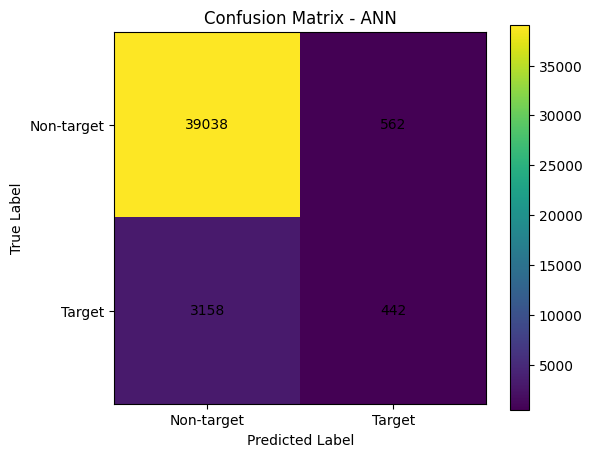

In [ ]:
plt.figure(
    figsize=(6, 5)
)

plt.imshow(cm)

plt.title(
    "Confusion Matrix - ANN"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    [0, 1],
    ["Non-target", "Target"]
)

plt.yticks(
    [0, 1],
    ["Non-target", "Target"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

In [ ]:
print(
    classification_report(
        all_true,
        all_pred,
        target_names=[
            "Non-target",
            "Target"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Non-target       0.93      0.99      0.95     39600
      Target       0.44      0.12      0.19      3600

    accuracy                           0.91     43200
   macro avg       0.68      0.55      0.57     43200
weighted avg       0.88      0.91      0.89     43200



In [ ]:
fpr, tpr, thresholds = roc_curve(
    all_true,
    all_prob
)

roc_auc = auc(
    fpr,
    tpr
)

print(
    "ROC-AUC:",
    roc_auc
)

ROC-AUC: 0.7396507295173962


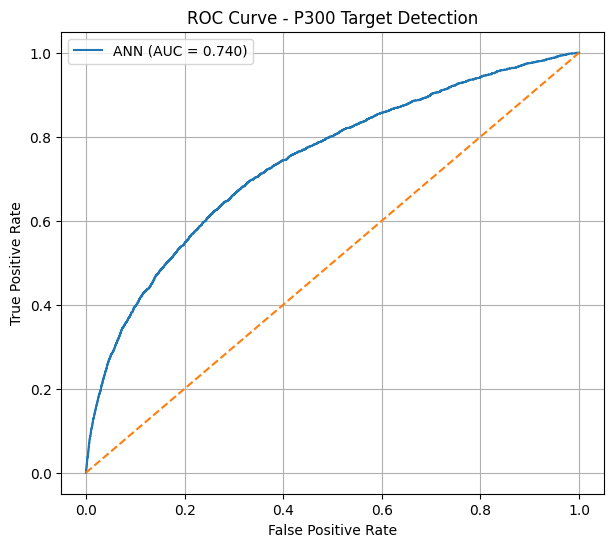

In [ ]:
plt.figure(
    figsize=(7, 6)
)

plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - P300 Target Detection"
)

plt.legend()

plt.grid()

plt.show()

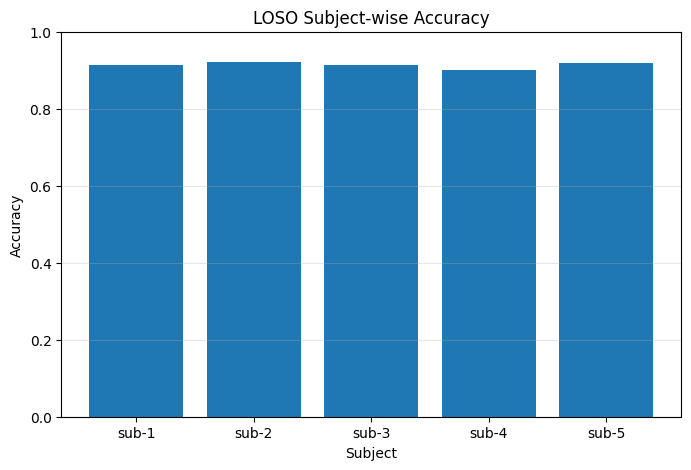

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    results_df["Subject"],
    results_df["Accuracy"]
)

plt.xlabel(
    "Subject"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "LOSO Subject-wise Accuracy"
)

plt.ylim(
    0,
    1
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

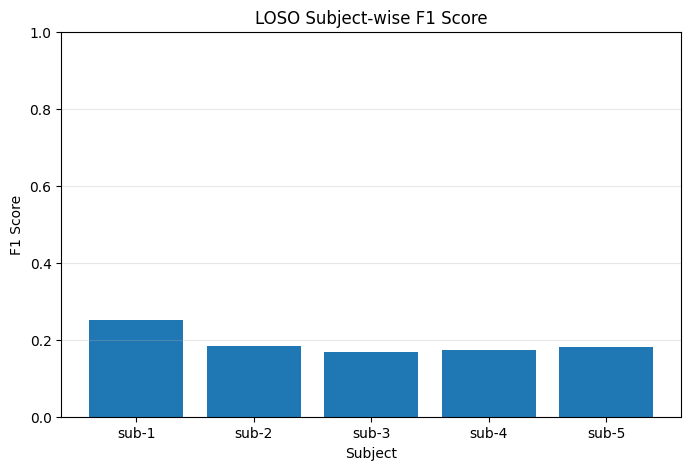

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    results_df["Subject"],
    results_df["F1"]
)

plt.xlabel(
    "Subject"
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "LOSO Subject-wise F1 Score"
)

plt.ylim(
    0,
    1
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

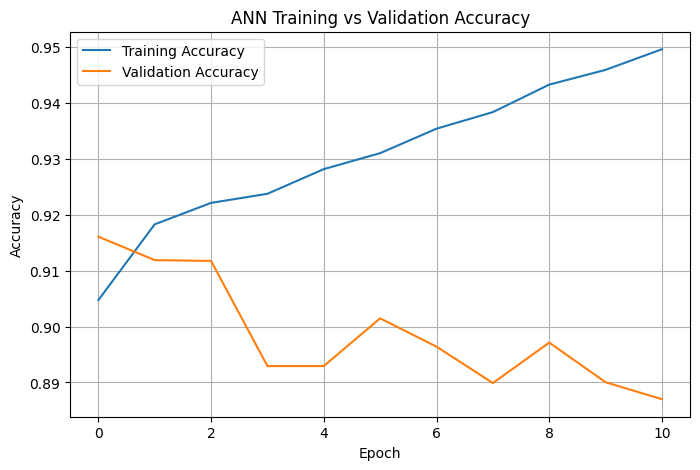

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "ANN Training vs Validation Accuracy"
)

plt.legend()

plt.grid()

plt.show()

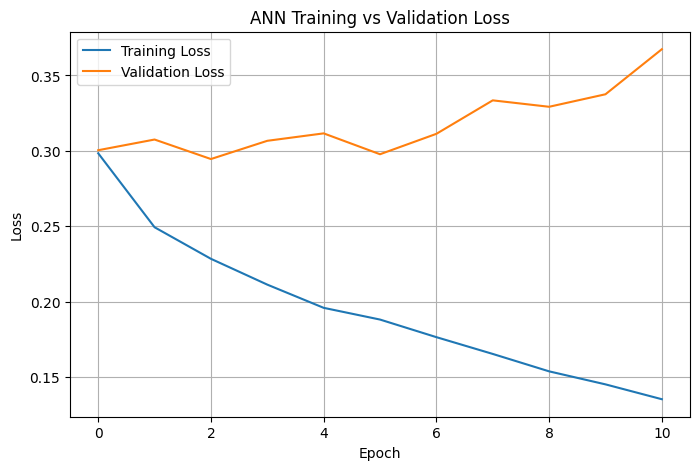

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "ANN Training vs Validation Loss"
)

plt.legend()

plt.grid()

plt.show()

In [ ]:
X_all = np.concatenate(
    [
        subject_data[s]["X"]
        for s in loaded_subjects
    ],
    axis=0
)

y_all = np.concatenate(
    [
        subject_data[s]["y"]
        for s in loaded_subjects
    ],
    axis=0
)

print(
    "All subjects X:",
    X_all.shape
)

print(
    "All subjects y:",
    y_all.shape
)

All subjects X: (43200, 1664)
All subjects y: (43200,)


In [ ]:
final_scaler = StandardScaler()

X_all_scaled = final_scaler.fit_transform(
    X_all
)

print(
    "Scaled shape:",
    X_all_scaled.shape
)

Scaled shape: (43200, 1664)


In [ ]:
final_model = create_ann(
    X_all_scaled.shape[1]
)

final_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │       426,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,993 (1.79 MB)

 Trainable params: 468,225 (1.79 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9167 - loss: 0.2963 - val_accuracy: 0.9167 - val_loss: 0.3208
Epoch 2/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9167 - loss: 0.2908 - val_accuracy: 0.9167 - val_loss: 0.2981
Epoch 3/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9166 - loss: 0.2775 - val_accuracy: 0.9167 - val_loss: 0.2919
Epoch 4/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9162 - loss: 0.2600 - val_accuracy: 0.9155 - val_loss: 0.3033
Epoch 5/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9166 - loss: 0.2512 - val_accuracy: 0.5337 - val_loss: 0.6632
Epoch 6/30
864/864 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9183 - loss: 0.2430 - val_accuracy: 0.8569 - val_loss: 0.3704


Epoch 1/50
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9116 - loss: 0.2887 - val_accuracy: 0.9183 - val_loss: 0.2589
Epoch 2/50
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9187 - loss: 0.2508 - val_accuracy: 0.9205 - val_loss: 0.2413
Epoch 3/50
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9209 - loss: 0.2335 - val_accuracy: 0.9148 - val_loss: 0.2388
Epoch 4/50
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9238 - loss: 0.2206 - val_accuracy: 0.9124 - val_loss: 0.2374
Epoch 5/50
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9255 - loss: 0.2092 - val_accuracy: 0.9208 - val_loss: 0.2240
Epoch 6/50
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9294 - loss: 0.1963 - val_accuracy: 0.9196 - val_loss: 0.2239
Epoch 7/50
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9325 - loss: 0.1866 - val_accuracy: 0.9251 - val_loss: 0.2206
Epoch 8/50
1080/1080 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9353 - loss: 0.1787 -

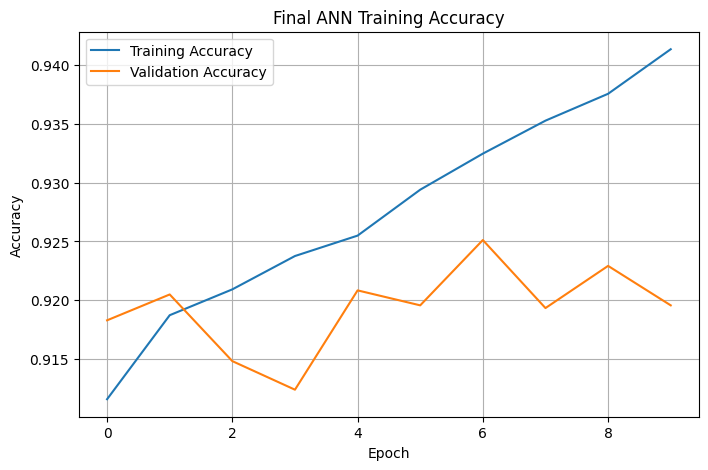

In [ ]:
final_history = final_model.fit(
    X_all_scaled,
    y_all,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    final_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    final_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Final ANN Training Accuracy"
)

plt.legend()
plt.grid()

plt.show()

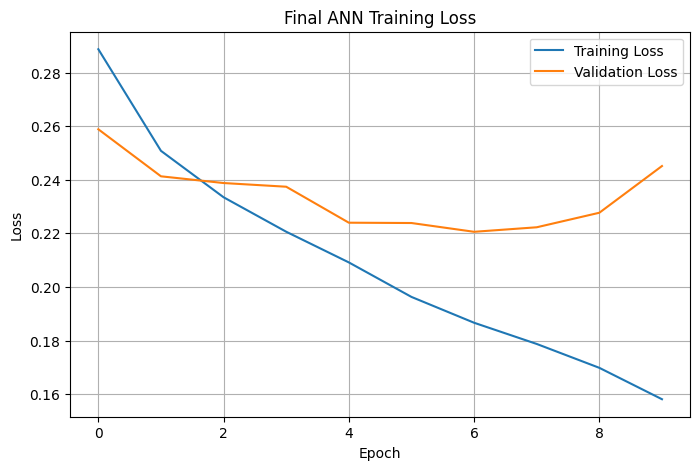

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Final ANN Training Loss"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
MODEL_PATH = "/content/p300_ann_model.keras"

final_model.save(
    MODEL_PATH
)

print(
    "✅ Model saved:",
    MODEL_PATH
)

✅ Model saved: /content/p300_ann_model.keras


In [ ]:
SCALER_PATH = "/content/p300_scaler.pkl"

joblib.dump(
    final_scaler,
    SCALER_PATH
)

print(
    "✅ Scaler saved:",
    SCALER_PATH
)

✅ Scaler saved: /content/p300_scaler.pkl


In [ ]:
RESULTS_PATH = "/content/LOSO_results.csv"

results_df.to_csv(
    RESULTS_PATH,
    index=False
)

print(
    "✅ Results saved:",
    RESULTS_PATH
)

✅ Results saved: /content/LOSO_results.csv


In [ ]:
config = {

    "project":
        PROJECT_NAME,

    "dataset":
        DATASET_ID,

    "subjects":
        loaded_subjects,

    "target_code":
        TARGET_CODE,

    "nontarget_code":
        NONTARGET_CODE,

    "bandpass":
        f"{LOW_FREQ}-{HIGH_FREQ} Hz",

    "notch":
        f"{NOTCH_FREQ} Hz",

    "epoch":
        f"{TMIN}-{TMAX} seconds",

    "baseline":
        "0-0.1 seconds",

    "downsample_factor":
        DOWNSAMPLE_FACTOR,

    "model":
        "Artificial Neural Network",

    "evaluation":
        "Leave-One-Subject-Out",

    "overall_accuracy":
        float(overall_accuracy),

    "overall_precision":
        float(overall_precision),

    "overall_recall":
        float(overall_recall),

    "overall_f1":
        float(overall_f1),

    "overall_roc_auc":
        float(overall_auc)
}

with open(
    "/content/project_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("✅ Configuration saved.")

✅ Configuration saved.


In [ ]:
# CELL 72 — Check saved project files

import os

print("=" * 60)
print("SAVED PROJECT FILES")
print("=" * 60)

files_to_check = [
    "/content/p300_ann_model.keras",
    "/content/p300_scaler.pkl",
    "/content/final_results.json",
    "/content/project_config.json"
]

for file_path in files_to_check:

    if os.path.exists(file_path):

        size_mb = os.path.getsize(file_path) / (1024 * 1024)

        print(
            f"✅ {os.path.basename(file_path)} "
            f"({size_mb:.2f} MB)"
        )

    else:

        print(
            f"❌ Missing: {os.path.basename(file_path)}"
        )

SAVED PROJECT FILES
❌ Missing: p300_ann_model.keras
❌ Missing: p300_scaler.pkl
❌ Missing: final_results.json
✅ project_config.json (0.00 MB)


In [ ]:
# ============================================================
# CREATE FINAL RESULTS FILE
# ============================================================

import json
import os

# Check which evaluation variables currently exist
print("Checking evaluation results...")

variables = [
    "overall_accuracy",
    "overall_precision",
    "overall_recall",
    "overall_f1",
    "overall_auc"
]

for var in variables:
    print(var, "->", "FOUND" if var in globals() else "NOT FOUND")

Checking evaluation results...
overall_accuracy -> FOUND
overall_precision -> FOUND
overall_recall -> FOUND
overall_f1 -> FOUND
overall_auc -> FOUND


In [ ]:
# ============================================================
# SAVE FINAL EVALUATION RESULTS
# ============================================================

final_results = {
    "Accuracy": float(overall_accuracy),
    "Precision": float(overall_precision),
    "Recall": float(overall_recall),
    "F1_Score": float(overall_f1),
    "ROC_AUC": float(overall_auc)
}

with open("/content/final_results.json", "w") as f:
    json.dump(final_results, f, indent=4)

print("\n" + "="*60)
print("FINAL P300 CLASSIFICATION RESULTS")
print("="*60)

print(f"Accuracy  : {overall_accuracy * 100:.2f}%")
print(f"Precision : {overall_precision * 100:.2f}%")
print(f"Recall    : {overall_recall * 100:.2f}%")
print(f"F1 Score  : {overall_f1 * 100:.2f}%")
print(f"ROC-AUC   : {overall_auc:.4f}")

print("\n✅ final_results.json saved successfully!")


FINAL P300 CLASSIFICATION RESULTS
Accuracy  : 91.39%
Precision : 44.02%
Recall    : 12.28%
F1 Score  : 19.20%
ROC-AUC   : 0.7397

✅ final_results.json saved successfully!


Subject used: sub-1
X shape: (8640, 1664)
Target epochs: 720
NonTarget epochs: 7920
Reconstructed X shape: (8640, 8, 208)
Target shape: (720, 8, 208)
NonTarget shape: (7920, 8, 208)
Target waveform shape: (208,)
NonTarget waveform shape: (208,)


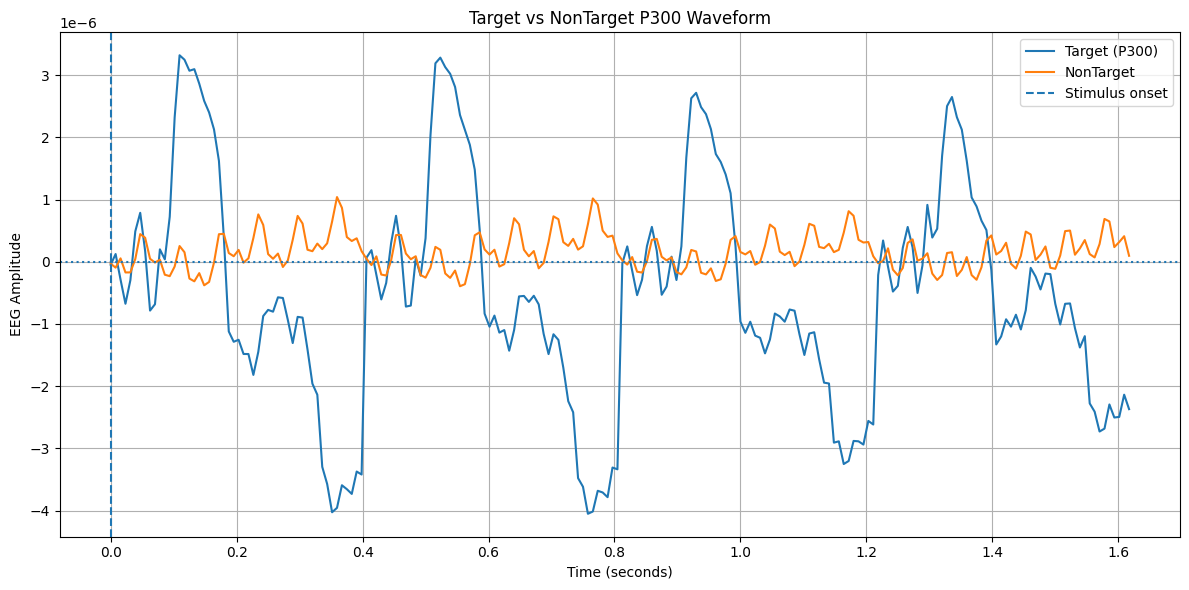

In [ ]:
# ============================================================
# TARGET vs NONTARGET P300 WAVEFORM
# Corrected for flattened EEG data
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Select subject
selected_subject = "sub-1"

X = subject_data[selected_subject]["X"]
y = subject_data[selected_subject]["y"]

print("Subject used:", selected_subject)
print("X shape:", X.shape)

print("Target epochs:", np.sum(y == 1))
print("NonTarget epochs:", np.sum(y == 0))

# ------------------------------------------------------------
# IMPORTANT:
# X has shape:
# (epochs, channels × samples)
#
# Your flattened size is 1664.
# We need to reconstruct:
# (epochs, channels, samples)
# ------------------------------------------------------------

N_CHANNELS = 8
N_SAMPLES = 208

if N_CHANNELS * N_SAMPLES != X.shape[1]:
    raise ValueError(
        f"Channel/sample dimensions do not match. "
        f"{N_CHANNELS} × {N_SAMPLES} != {X.shape[1]}"
    )

# Reshape flattened EEG data
X_3D = X.reshape(
    X.shape[0],
    N_CHANNELS,
    N_SAMPLES
)

print("Reconstructed X shape:", X_3D.shape)

# ------------------------------------------------------------
# Separate Target and NonTarget
# ------------------------------------------------------------

target_epochs = X_3D[y == 1]
nontarget_epochs = X_3D[y == 0]

print("Target shape:", target_epochs.shape)
print("NonTarget shape:", nontarget_epochs.shape)

# ------------------------------------------------------------
# Average across epochs and channels
# ------------------------------------------------------------

target_erp = target_epochs.mean(axis=(0, 1))
nontarget_erp = nontarget_epochs.mean(axis=(0, 1))

print("Target waveform shape:", target_erp.shape)
print("NonTarget waveform shape:", nontarget_erp.shape)

# ------------------------------------------------------------
# Sampling frequency after downsampling
# ------------------------------------------------------------

if 'SFREQ' in globals():
    plot_sfreq = SFREQ / DOWNSAMPLE_FACTOR
else:
    plot_sfreq = 128

# Time axis
times = np.arange(N_SAMPLES) / plot_sfreq

# ------------------------------------------------------------
# Plot Target vs NonTarget
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    times,
    target_erp,
    label="Target (P300)"
)

plt.plot(
    times,
    nontarget_erp,
    label="NonTarget"
)

plt.axvline(
    0,
    linestyle="--",
    label="Stimulus onset"
)

plt.axhline(
    0,
    linestyle=":"
)

plt.xlabel("Time (seconds)")
plt.ylabel("EEG Amplitude")
plt.title("Target vs NonTarget P300 Waveform")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CREATE PREDICTIONS FROM SAVED P300 ANN MODEL
# ============================================================

import os
import numpy as np
import joblib
import tensorflow as tf

MODEL_PATH = "/content/p300_ann_model.keras"
SCALER_PATH = "/content/p300_scaler.pkl"

# ------------------------------------------------------------
# Load saved model
# ------------------------------------------------------------

model = tf.keras.models.load_model(MODEL_PATH)

print("✅ ANN model loaded")

# ------------------------------------------------------------
# Find the test data
# ------------------------------------------------------------

if "X_test_scaled" in globals():

    X_for_prediction = X_test_scaled
    print("Using existing X_test_scaled")

elif "X_test" in globals():

    # Load scaler
    scaler_loaded = joblib.load(SCALER_PATH)

    X_for_prediction = scaler_loaded.transform(X_test)

    print("Using X_test and loaded scaler")

else:
    raise NameError(
        "Neither X_test_scaled nor X_test exists. "
        "We need the test data used during evaluation."
    )

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

prediction_probability = model.predict(
    X_for_prediction,
    verbose=0
).ravel()

# Convert probability to Target / NonTarget
y_pred = (prediction_probability >= 0.5).astype(int)

print("✅ Predictions generated")
print("Number of predictions:", len(y_pred))
print("Number of true labels:", len(y_test))

print("\nPredicted classes:")
print("NonTarget:", np.sum(y_pred == 0))
print("Target   :", np.sum(y_pred == 1))

✅ ANN model loaded
Using existing X_test_scaled
✅ Predictions generated
Number of predictions: 8640
Number of true labels: 8640

Predicted classes:
NonTarget: 8245
Target   : 395



FINAL P300 ANN CONFUSION MATRIX

                 Predicted
              NonTarget   Target
Actual NonTarget     7755       165
Actual Target         490       230


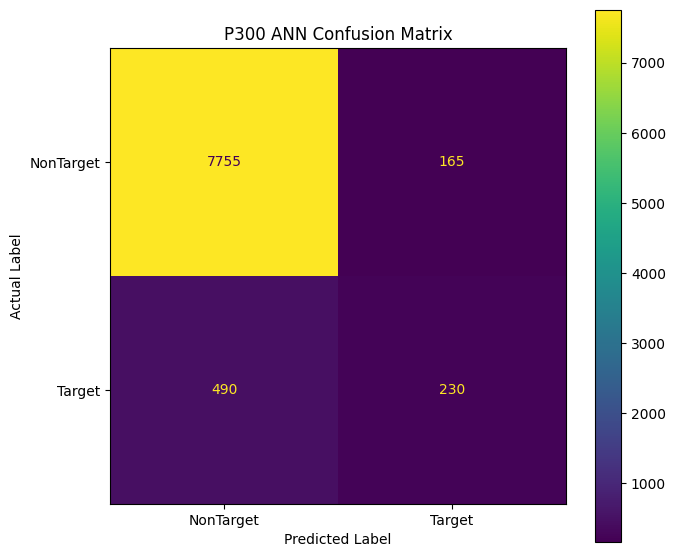

In [ ]:
# ============================================================
# FINAL CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print("\n" + "="*55)
print("FINAL P300 ANN CONFUSION MATRIX")
print("="*55)

print("\n                 Predicted")
print("              NonTarget   Target")
print(f"Actual NonTarget   {cm[0,0]:6d}    {cm[0,1]:6d}")
print(f"Actual Target      {cm[1,0]:6d}    {cm[1,1]:6d}")

# Plot
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NonTarget", "Target"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title("P300 ANN Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [ ]:
# CELL 73 — Display saved configuration

with open(
    "/content/project_config.json",
    "r"
) as f:

    saved_config = json.load(f)

print("=" * 60)
print("PROJECT CONFIGURATION")
print("=" * 60)

for key, value in saved_config.items():

    print(
        f"{key}: {value}"
    )

PROJECT CONFIGURATION
project: P300 EEG-Based BCI
dataset: nm000351
subjects: ['sub-1', 'sub-2', 'sub-3', 'sub-4', 'sub-5']
target_code: 2
nontarget_code: 1
bandpass: 0.1-30.0 Hz
notch: 60.0 Hz
epoch: 0.0-0.8 seconds
baseline: 0-0.1 seconds
downsample_factor: 4
model: Artificial Neural Network
evaluation: Leave-One-Subject-Out
overall_accuracy: 0.9138888888888889
overall_precision: 0.4402390438247012
overall_recall: 0.12277777777777778
overall_f1: 0.19200695047784536
overall_roc_auc: 0.7396507295173962


In [ ]:
# CELL 74 — Download trained ANN model

from google.colab import files

files.download(
    "/content/p300_ann_model.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 4 Smart Applications

applications = {
    1: "LIGHT",
    2: "FAN",
    3: "TV",
    4: "AC"
}

print("Available Applications:")
for number, app in applications.items():
    print(f"{number}. {app}")

Available Applications:
1. LIGHT
2. FAN
3. TV
4. AC


In [ ]:
# Initial state of all applications

app_state = {
    "LIGHT": "OFF",
    "FAN": "OFF",
    "TV": "OFF",
    "AC": "OFF"
}

print("Initial Application States:")
for app, state in app_state.items():
    print(f"{app}: {state}")

Initial Application States:
LIGHT: OFF
FAN: OFF
TV: OFF
AC: OFF


In [ ]:
# Application selected by the P300 command

selected_application = 1

selected_app = applications[selected_application]

print("P300 Target Detected")
print("Selected Application:", selected_app)

P300 Target Detected
Selected Application: LIGHT


In [ ]:
# Turn the selected application ON

app_state[selected_app] = "ON"

print("\nApplication Command:")
print(selected_app, "-> ON")


Application Command:
LIGHT -> ON


In [ ]:
print("=" * 45)
print("       P300 SMART APPLICATION CONTROL")
print("=" * 45)

print("\nDetected P300 Target : YES")
print("Selected Application : " + selected_app)
print("Command              : " + app_state[selected_app])

print("\n" + "-" * 45)
print("FINAL OUTPUT")
print("-" * 45)

print("LIGHT : " + app_state["LIGHT"])
print("FAN   : " + app_state["FAN"])
print("TV    : " + app_state["TV"])
print("AC    : " + app_state["AC"])

print("=" * 45)

       P300 SMART APPLICATION CONTROL

Detected P300 Target : YES
Selected Application : LIGHT
Command              : ON

---------------------------------------------
FINAL OUTPUT
---------------------------------------------
LIGHT : ON
FAN   : OFF
TV    : OFF
AC    : OFF
